# ERD Generator from SQL

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/erd-generator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/erd-generator/demo.ipynb)

> Paste SQL CREATE TABLE statements, get an instant ER diagram — no database connection needed.

**What this notebook covers:**
1. Parsing SQL DDL into structured schema metadata
2. Detecting primary keys, foreign keys, and relationships
3. Generating Mermaid ER diagram syntax
4. Visualizing the schema as a graph with matplotlib

## Step 1: Define the SQL Parser

The parser uses regex to extract table names, columns, types, primary keys, and foreign key relationships from standard `CREATE TABLE` statements. It handles inline `REFERENCES` and standalone `FOREIGN KEY` constraints.

In [1]:
from __future__ import annotations

import re
from typing import Dict, List


def parse_sql(sql: str) -> Dict[str, Dict]:
    """Parse CREATE TABLE statements into structured schema dict."""
    tables: Dict[str, Dict] = {}
    sql_clean = re.sub(r'--[^\n]*', '', sql)
    sql_clean = re.sub(r'/\*.*?\*/', '', sql_clean, flags=re.DOTALL)

    pattern = re.compile(
        r'CREATE\s+TABLE\s+(?:IF\s+NOT\s+EXISTS\s+)?[`"\'\s]*(\w+)[`"\'\s]*\((.*?)\)\s*;',
        re.IGNORECASE | re.DOTALL,
    )

    for match in pattern.finditer(sql_clean):
        table_name = match.group(1).lower()
        body = match.group(2)
        columns: List[Dict] = []
        foreign_keys: List[Dict] = []

        for line in body.split(','):
            line = line.strip()
            if not line:
                continue

            fk_match = re.match(
                r'FOREIGN\s+KEY\s*\(\s*[`"\'\s]*(\w+)[`"\'\s]*\)\s*REFERENCES\s+[`"\'\s]*(\w+)[`"\'\s]*\(\s*[`"\'\s]*(\w+)[`"\'\s]*\)',
                line, re.IGNORECASE,
            )
            if fk_match:
                foreign_keys.append({
                    'column': fk_match.group(1).lower(),
                    'ref_table': fk_match.group(2).lower(),
                    'ref_column': fk_match.group(3).lower(),
                })
                continue

            if re.match(r'(PRIMARY\s+KEY|UNIQUE|INDEX|CHECK|CONSTRAINT)', line, re.IGNORECASE):
                pk_match = re.match(r'PRIMARY\s+KEY\s*\(\s*([^)]+)\)', line, re.IGNORECASE)
                if pk_match:
                    pk_cols = [c.strip().strip('`"\'').lower() for c in pk_match.group(1).split(',')]
                    for col in columns:
                        if col['name'] in pk_cols:
                            col['primary_key'] = True
                continue

            col_match = re.match(r'[`"\'\s]*(\w+)[`"\'\s]+([\w]+(?:\s*\([^)]*\))?)', line, re.IGNORECASE)
            if col_match:
                col_name = col_match.group(1).lower()
                col_type = col_match.group(2).upper()
                is_pk = bool(re.search(r'PRIMARY\s+KEY', line, re.IGNORECASE))
                is_nn = bool(re.search(r'NOT\s+NULL', line, re.IGNORECASE))

                inline_ref = re.search(
                    r'REFERENCES\s+[`"\'\s]*(\w+)[`"\'\s]*\(\s*[`"\'\s]*(\w+)[`"\'\s]*\)',
                    line, re.IGNORECASE,
                )
                if inline_ref:
                    foreign_keys.append({
                        'column': col_name,
                        'ref_table': inline_ref.group(1).lower(),
                        'ref_column': inline_ref.group(2).lower(),
                    })

                columns.append({
                    'name': col_name,
                    'type': col_type,
                    'primary_key': is_pk,
                    'not_null': is_nn,
                })

        tables[table_name] = {'columns': columns, 'foreign_keys': foreign_keys}

    return tables


print('Parser ready.')

Parser ready.


## Step 2: Sample SQL Schema

A realistic 4-table company database with departments, employees, projects, and assignments. This exercises primary keys, foreign keys (including self-referencing), and various column types.

In [2]:
SAMPLE_SQL = """
CREATE TABLE departments (
    id INTEGER PRIMARY KEY,
    name VARCHAR(100) NOT NULL,
    location VARCHAR(200)
);

CREATE TABLE employees (
    id INTEGER PRIMARY KEY,
    first_name VARCHAR(50) NOT NULL,
    last_name VARCHAR(50) NOT NULL,
    email VARCHAR(100) NOT NULL,
    department_id INTEGER NOT NULL,
    manager_id INTEGER,
    hire_date DATE NOT NULL,
    salary DECIMAL(10,2),
    FOREIGN KEY (department_id) REFERENCES departments(id),
    FOREIGN KEY (manager_id) REFERENCES employees(id)
);

CREATE TABLE projects (
    id INTEGER PRIMARY KEY,
    name VARCHAR(100) NOT NULL,
    start_date DATE,
    end_date DATE,
    budget DECIMAL(12,2),
    department_id INTEGER,
    FOREIGN KEY (department_id) REFERENCES departments(id)
);

CREATE TABLE assignments (
    id INTEGER PRIMARY KEY,
    employee_id INTEGER NOT NULL,
    project_id INTEGER NOT NULL,
    role VARCHAR(50),
    hours_allocated INTEGER,
    FOREIGN KEY (employee_id) REFERENCES employees(id),
    FOREIGN KEY (project_id) REFERENCES projects(id)
);
"""

tables = parse_sql(SAMPLE_SQL)
print(f'Parsed {len(tables)} tables: {", ".join(tables.keys())}')

for tname, info in tables.items():
    pk_cols = [c['name'] for c in info['columns'] if c['primary_key']]
    fk_cols = [f['column'] for f in info['foreign_keys']]
    print(f'\n  {tname}: {len(info["columns"])} columns | PK: {pk_cols} | FK: {fk_cols}')
    for col in info['columns']:
        flags = []
        if col['primary_key']: flags.append('PK')
        if col['not_null']: flags.append('NN')
        if col['name'] in fk_cols: flags.append('FK')
        flag_str = f" [{', '.join(flags)}]" if flags else ''
        print(f'    {col["name"]:20s} {col["type"]:15s}{flag_str}')

Parsed 4 tables: departments, employees, projects, assignments

  departments: 3 columns | PK: ['id'] | FK: []
    id                   INTEGER         [PK]
    name                 VARCHAR(100)    [NN]
    location             VARCHAR(200)   

  employees: 8 columns | PK: ['id'] | FK: ['department_id', 'manager_id']
    id                   INTEGER         [PK]
    first_name           VARCHAR(50)     [NN]
    last_name            VARCHAR(50)     [NN]
    email                VARCHAR(100)    [NN]
    department_id        INTEGER         [NN, FK]
    manager_id           INTEGER         [FK]
    hire_date            DATE            [NN]
    salary               DECIMAL        

  projects: 6 columns | PK: ['id'] | FK: ['department_id']
    id                   INTEGER         [PK]
    name                 VARCHAR(100)    [NN]
    start_date           DATE           
    end_date             DATE           
    budget               DECIMAL        
    department_id        INTEGER       

## Step 3: Generate Mermaid ER Diagram

Mermaid is supported natively in GitHub markdown, Notion, and many documentation tools. This output can be pasted directly into a README or `.md` file.

In [3]:
def generate_mermaid(tables: Dict[str, Dict]) -> str:
    """Generate Mermaid erDiagram syntax."""
    lines = ['erDiagram']

    for table_name, info in tables.items():
        lines.append(f'    {table_name} {{')
        for col in info['columns']:
            pk_marker = ' PK' if col['primary_key'] else ''
            fk_marker = ''
            for fk in info['foreign_keys']:
                if fk['column'] == col['name']:
                    fk_marker = ' FK'
                    break
            col_type = col['type'].replace(' ', '_')
            lines.append(f'        {col_type} {col["name"]}{pk_marker}{fk_marker}')
        lines.append('    }')

    for table_name, info in tables.items():
        for fk in info['foreign_keys']:
            ref = fk['ref_table']
            lines.append(f'    {ref} ||--o{{ {table_name} : "{fk["column"]}')

    return '\n'.join(lines)


mermaid_output = generate_mermaid(tables)
print(mermaid_output)

erDiagram
    departments {
        INTEGER id PK
        VARCHAR(100) name
        VARCHAR(200) location
    }
    employees {
        INTEGER id PK
        VARCHAR(50) first_name
        VARCHAR(50) last_name
        VARCHAR(100) email
        INTEGER department_id FK
        INTEGER manager_id FK
        DATE hire_date
        DECIMAL salary
    }
    projects {
        INTEGER id PK
        VARCHAR(100) name
        DATE start_date
        DATE end_date
        DECIMAL budget
        INTEGER department_id FK
    }
    assignments {
        INTEGER id PK
        INTEGER employee_id FK
        INTEGER project_id FK
        VARCHAR(50) role
        INTEGER hours_allocated
    }
    departments ||--o{ employees : "department_id
    employees ||--o{ employees : "manager_id
    departments ||--o{ projects : "department_id
    employees ||--o{ assignments : "employee_id
    projects ||--o{ assignments : "project_id


## Step 4: Visualize the Schema Graph

Since notebooks can't render Mermaid natively, we build a visual representation using matplotlib. Tables are drawn as labeled boxes, and foreign key relationships are shown as arrows.

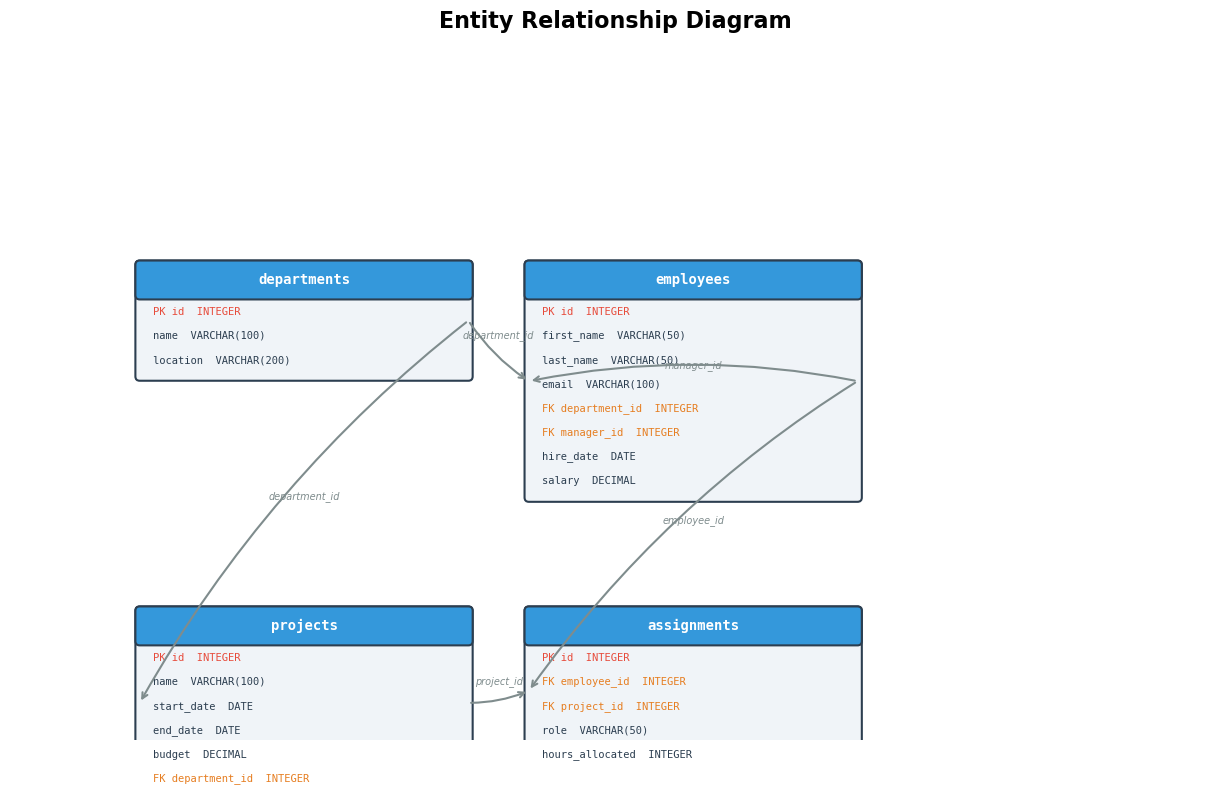

Diagram saved to erd_diagram.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def draw_erd(tables: Dict[str, Dict], save_path: str = 'erd_diagram.png') -> None:
    """Draw an ERD using matplotlib."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Entity Relationship Diagram', fontsize=16, fontweight='bold', pad=15)

    positions = {
        'departments': (1.5, 5.5),
        'employees': (6.0, 5.5),
        'projects': (1.5, 1.5),
        'assignments': (6.0, 1.5),
    }

    table_names = list(tables.keys())
    if not all(t in positions for t in table_names):
        cols = 3
        positions = {}
        for i, t in enumerate(table_names):
            row, col = divmod(i, cols)
            positions[t] = (1.5 + col * 4.5, 6.0 - row * 4.0)

    box_w, header_h, row_h = 3.8, 0.35, 0.28
    table_boxes = {}

    for tname, info in tables.items():
        x, y = positions[tname]
        n_cols = len(info['columns'])
        box_h = header_h + row_h * n_cols + 0.1

        rect = mpatches.FancyBboxPatch(
            (x, y - box_h), box_w, box_h,
            boxstyle='round,pad=0.05', facecolor='#f0f4f8',
            edgecolor='#2c3e50', linewidth=1.5,
        )
        ax.add_patch(rect)
        table_boxes[tname] = (x, y, x + box_w, y - box_h)

        header_rect = mpatches.FancyBboxPatch(
            (x, y - header_h), box_w, header_h,
            boxstyle='round,pad=0.05', facecolor='#3498db',
            edgecolor='#2c3e50', linewidth=1.5,
        )
        ax.add_patch(header_rect)
        ax.text(x + box_w / 2, y - header_h / 2, tname,
                ha='center', va='center', fontsize=10,
                fontweight='bold', color='white', family='monospace')

        fk_col_names = {f['column'] for f in info['foreign_keys']}
        for i, col in enumerate(info['columns']):
            cy = y - header_h - 0.05 - row_h * i - row_h / 2
            prefix = ''
            if col['primary_key']:
                prefix = 'PK '
            elif col['name'] in fk_col_names:
                prefix = 'FK '
            label = f"{prefix}{col['name']}  {col['type']}"
            color = '#e74c3c' if col['primary_key'] else ('#e67e22' if col['name'] in fk_col_names else '#2c3e50')
            ax.text(x + 0.15, cy, label, ha='left', va='center',
                    fontsize=7.5, color=color, family='monospace')

    for tname, info in tables.items():
        for fk in info['foreign_keys']:
            ref = fk['ref_table']
            if ref not in table_boxes or tname not in table_boxes:
                continue
            sx = table_boxes[ref][2]
            sy = (table_boxes[ref][1] + table_boxes[ref][3]) / 2
            ex = table_boxes[tname][0]
            ey = (table_boxes[tname][1] + table_boxes[tname][3]) / 2

            if abs(sx - ex) < 0.1:
                sx = (table_boxes[ref][0] + table_boxes[ref][2]) / 2
                sy = table_boxes[ref][3]
                ex = (table_boxes[tname][0] + table_boxes[tname][2]) / 2
                ey = table_boxes[tname][1]

            ax.annotate(
                '', xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5,
                                connectionstyle='arc3,rad=0.1'),
            )
            mx, my = (sx + ex) / 2, (sy + ey) / 2
            ax.text(mx, my + 0.15, fk['column'], fontsize=7,
                    ha='center', color='#7f8c8d', style='italic')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Diagram saved to {save_path}')


draw_erd(tables)

## Step 5: Schema Statistics

A quick summary of the parsed schema — useful for documentation and data governance.

In [5]:
print('=' * 50)
print('SCHEMA SUMMARY')
print('=' * 50)
total_cols = sum(len(t['columns']) for t in tables.values())
total_fks = sum(len(t['foreign_keys']) for t in tables.values())
total_pks = sum(1 for t in tables.values() for c in t['columns'] if c['primary_key'])

print(f'Tables:            {len(tables)}')
print(f'Total columns:     {total_cols}')
print(f'Primary keys:      {total_pks}')
print(f'Foreign keys:      {total_fks}')
print(f'Avg cols/table:    {total_cols / len(tables):.1f}')
print()

print('RELATIONSHIPS:')
for tname, info in tables.items():
    for fk in info['foreign_keys']:
        print(f'  {tname}.{fk["column"]} -> {fk["ref_table"]}.{fk["ref_column"]}')

SCHEMA SUMMARY
Tables:            4
Total columns:     22
Primary keys:      4
Foreign keys:      5
Avg cols/table:    5.5

RELATIONSHIPS:
  employees.department_id -> departments.id
  employees.manager_id -> employees.id
  projects.department_id -> departments.id
  assignments.employee_id -> employees.id
  assignments.project_id -> projects.id


## Try Your Own

Replace the SQL below with your own `CREATE TABLE` statements and re-run the cells above.

In [6]:
# YOUR_SQL = """
# CREATE TABLE customers (
#     id INTEGER PRIMARY KEY,
#     name VARCHAR(100) NOT NULL,
#     email VARCHAR(150)
# );
#
# CREATE TABLE orders (
#     id INTEGER PRIMARY KEY,
#     customer_id INTEGER NOT NULL,
#     total DECIMAL(10,2),
#     FOREIGN KEY (customer_id) REFERENCES customers(id)
# );
# """
#
# my_tables = parse_sql(YOUR_SQL)
# print(generate_mermaid(my_tables))
# draw_erd(my_tables, save_path='my_erd.png')

---

**Part of the [FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** | For the full Streamlit app, run `streamlit run app.py`